In [1]:
import torch 
import torch.nn as nn
import numpy as np
from torch.nn import Parameter
import torch.nn.functional as F
import torch.optim as optim
from sklearn import metrics
import os
from tqdm import tqdm


from torch_geometric.utils import to_undirected, subgraph
from torch_geometric.data import Data, Batch, DataLoader

from config import config_train, config_test
from data_process import data_process_all_chrom, data_process

import models
from sampler import *
from aggregator import MaxminMeanAggregator

import utils
from batch import load_val

/public/home/wuyy/miniconda3/envs/torch/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def model_eval(data, test_batchloader, model, Aggregator):
    model.eval()
    Aggregator.eval()
    with torch.no_grad():
        total_pred = []
        test_label = []
        num_data = 0

        v = model(data.x, data.edge_index, data.edge_attr)
        
        while True :
            hedges, labels, is_last = test_batchloader.next()
            batch_size = len(hedges)
            num_data+=batch_size
            for hedge in hedges :
                embeddings = v[hedge]
                #pred, _ = Aggregator(embeddings)
                max_min_dist = torch.max(hedge) - torch.min(hedge)
                pred, _ = Aggregator(max_min_dist,embeddings)
                total_pred.append(pred.detach())
            test_label.append(labels.detach())
            
            if is_last :
                break
        total_pred = torch.stack(total_pred)       
        total_pred = total_pred.squeeze()
        test_label = torch.cat(test_label, dim=0)
        

    return total_pred.tolist(), test_label.tolist()

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [5]:
dim_edge = 400
dim_vertex = 400

alpha_e = 0
alpha_v = 0

input_dim = 15 #features_num

n_layers = 1

size = 1000
nv = size

memory_size = 0

lr = 0.00004

bs = 512

memory_size = 0
clip = 0.01
n_layers = 3


In [6]:
model_dir = 'models/GM12878/'

model = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model.to(device)

if model_dir:
    model.load_state_dict(torch.load(model_dir+"model_epoch_7"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator.to(device)

if model_dir:
    Aggregator.load_state_dict(torch.load(model_dir+"Aggregator_epoch_7"))

In [7]:
import pickle

In [14]:

chr_results = {}

for chr_name in ["chr14", "chr22", "chrX"]:

    with open("chrom_data/GM12878/"+chr_name+"_sliding_data","rb") as f:
        sliding_data = pickle.load(f)
        
        
    mns_aucs = []
    mns_aps = []
    sns_aucs = []
    sns_aps = []
    cns_aucs = []
    cns_aps = []
    rwcns_aucs = []
    rwcns_aps = []

    for data in sliding_data:
    
        if len(data.hyper_edge) < bs:
            continue

        data = data.to(device)
        
        test_batchloader = load_val(data.hyper_edge, bs, device, label="pos")
        val_pred_pos, total_label_pos = model_eval(data, test_batchloader, model, Aggregator)
                
        test_batchloader = load_val(data.mns, bs, device, label="mns")
        val_pred_mns, total_label_mns = model_eval(data, test_batchloader, model, Aggregator)
        mns_auc = metrics.roc_auc_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        mns_ap = metrics.average_precision_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        
        test_batchloader = load_val(data.sns, bs, device, label="sns")
        val_pred_sns, total_label_sns = model_eval(data, test_batchloader, model, Aggregator)
        sns_auc = metrics.roc_auc_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)
        sns_ap = metrics.average_precision_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)        
        
        test_batchloader = load_val(data.cns, bs, device, label="cns")
        val_pred_cns, total_label_cns = model_eval(data, test_batchloader, model, Aggregator)
        cns_auc = metrics.roc_auc_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)
        cns_ap = metrics.average_precision_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)        
    
    
        mns_aucs.append(mns_auc)
        mns_aps.append(mns_ap)
        sns_aucs.append(sns_auc)
        sns_aps.append(sns_ap)
        cns_aucs.append(cns_auc)
        cns_aps.append(cns_ap)
    
    
    chr_results[chr_name] = [mns_aucs, sns_aucs, cns_aucs, mns_aps, sns_aps, cns_aps]

    mns_aucs = np.mean(mns_aucs)
    mns_aps = np.mean(mns_aps)
    sns_aucs = np.mean(sns_aucs)
    sns_aps = np.mean(sns_aps)
    cns_aucs = np.mean(cns_aucs)
    cns_aps = np.mean(cns_aps)


    print("Chr:"+chr_name)
    print("Val mns AUC:"+str(mns_aucs)+",Val mns AP:"+str(mns_aps))
    print("Val sns AUC:"+str(sns_aucs)+",Val sns AP:"+str(sns_aps))
    print("Val cns AUC:"+str(cns_aucs)+",Val cns AP:"+str(cns_aps))
    

Chr:chr14
Val mns AUC:0.9030794207752842,Val mns AP:0.9111421425742791
Val sns AUC:0.955667481439109,Val sns AP:0.9583229677734113
Val cns AUC:0.6963015182852078,Val cns AP:0.7221283413081342
Chr:chr22
Val mns AUC:0.9054782635495777,Val mns AP:0.9138946739325794
Val sns AUC:0.9595734056058318,Val sns AP:0.9622540678090004
Val cns AUC:0.6976320168342527,Val cns AP:0.7245745505779867
Chr:chrX
Val mns AUC:0.8422066546580658,Val mns AP:0.8602448944473795
Val sns AUC:0.9177015124577166,Val sns AP:0.9254146749064485
Val cns AUC:0.6446754752301442,Val cns AP:0.6759418756938568


In [15]:
chr_GM12878 = chr_results

In [16]:
model_dir = 'models/K562/'

model = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model.to(device)

if model_dir:
    model.load_state_dict(torch.load(model_dir+"model_epoch_9"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator.to(device)

if model_dir:
    Aggregator.load_state_dict(torch.load(model_dir+"Aggregator_epoch_9"))

In [17]:

chr_results = {}

for chr_name in ["chr14", "chr22", "chrX"]:

    with open("chrom_data/K562/"+chr_name+"_sliding_data","rb") as f:
        sliding_data = pickle.load(f)
        
        
    mns_aucs = []
    mns_aps = []
    sns_aucs = []
    sns_aps = []
    cns_aucs = []
    cns_aps = []
    rwcns_aucs = []
    rwcns_aps = []

    for data in sliding_data:
    
        if len(data.hyper_edge) < bs:
            continue

        data = data.to(device)
        
        test_batchloader = load_val(data.hyper_edge, bs, device, label="pos")
        val_pred_pos, total_label_pos = model_eval(data, test_batchloader, model, Aggregator)
                
        test_batchloader = load_val(data.mns, bs, device, label="mns")
        val_pred_mns, total_label_mns = model_eval(data, test_batchloader, model, Aggregator)
        mns_auc = metrics.roc_auc_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        mns_ap = metrics.average_precision_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        
        test_batchloader = load_val(data.sns, bs, device, label="sns")
        val_pred_sns, total_label_sns = model_eval(data, test_batchloader, model, Aggregator)
        sns_auc = metrics.roc_auc_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)
        sns_ap = metrics.average_precision_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)        
        
        test_batchloader = load_val(data.cns, bs, device, label="cns")
        val_pred_cns, total_label_cns = model_eval(data, test_batchloader, model, Aggregator)
        cns_auc = metrics.roc_auc_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)
        cns_ap = metrics.average_precision_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)        
    
    
        mns_aucs.append(mns_auc)
        mns_aps.append(mns_ap)
        sns_aucs.append(sns_auc)
        sns_aps.append(sns_ap)
        cns_aucs.append(cns_auc)
        cns_aps.append(cns_ap)
    
    
    chr_results[chr_name] = [mns_aucs, sns_aucs, cns_aucs, mns_aps, sns_aps, cns_aps]

    mns_aucs = np.mean(mns_aucs)
    mns_aps = np.mean(mns_aps)
    sns_aucs = np.mean(sns_aucs)
    sns_aps = np.mean(sns_aps)
    cns_aucs = np.mean(cns_aucs)
    cns_aps = np.mean(cns_aps)


    print("Chr:"+chr_name)
    print("Val mns AUC:"+str(mns_aucs)+",Val mns AP:"+str(mns_aps))
    print("Val sns AUC:"+str(sns_aucs)+",Val sns AP:"+str(sns_aps))
    print("Val cns AUC:"+str(cns_aucs)+",Val cns AP:"+str(cns_aps))
    

Chr:chr14
Val mns AUC:0.880176843869657,Val mns AP:0.8904256019317301
Val sns AUC:0.9438176290827467,Val sns AP:0.9484207682025699
Val cns AUC:0.6466663499606708,Val cns AP:0.6735947180485792
Chr:chr22
Val mns AUC:0.8909402839359557,Val mns AP:0.9002467694897065
Val sns AUC:0.9468432640151789,Val sns AP:0.9504742639605323
Val cns AUC:0.6745939757258217,Val cns AP:0.700999434862843
Chr:chrX
Val mns AUC:0.8372695252904154,Val mns AP:0.8541196622086915
Val sns AUC:0.9126109688734709,Val sns AP:0.9214342527479599
Val cns AUC:0.6224230889645022,Val cns AP:0.651185186644851


In [18]:
chr_K562 = chr_results

In [19]:
chr_GM12878

{'chr14': [[0.8525397548207196,
   0.937998618032628,
   0.8399954012321007,
   0.9254533245511944,
   0.8825767797191819,
   0.8662334383625221,
   0.8475405921267173,
   0.9256937296182155,
   0.9100765246925633,
   0.9358404943460839,
   0.9407361786263557,
   0.9487562007275157,
   0.8947700620939167,
   0.8636487124606387,
   0.9009054663310451,
   0.927362760887428,
   0.897066760277949,
   0.932356485167364,
   0.9289577106562583],
  [0.9492633004257168,
   0.9754509967396507,
   0.9154808975892088,
   0.9644595527613935,
   0.94159150602427,
   0.9212462364738214,
   0.9466109698547248,
   0.9612785805410611,
   0.9563070561277853,
   0.9746539169982587,
   0.9744039752227056,
   0.9787317252135029,
   0.9559069661257428,
   0.9155261870263641,
   0.9582999626145692,
   0.9611586753044552,
   0.9532586689238253,
   0.9784795151815395,
   0.9755734581944737],
  [0.6579920040657878,
   0.7247733132707093,
   0.6560432189680183,
   0.7059862492234213,
   0.6711202325599104,
   0.6

In [20]:
chr_K562

{'chr14': [[0.8312409876985696,
   0.9182697478377706,
   0.8473382081041878,
   0.9079981748926688,
   0.8791180243410446,
   0.8021618949754254,
   0.8340090230106689,
   0.9009660093848052,
   0.8918227254445388,
   0.9097962417371273,
   0.9026881021448331,
   0.9287142454463841,
   0.8664953803117545,
   0.8028037524730034,
   0.8734137390770932,
   0.9039851156231274,
   0.8943970163502786,
   0.9187226186974078,
   0.9094190259727942],
  [0.9018183288460612,
   0.9742323032787003,
   0.9307965900012997,
   0.9498721497464574,
   0.9485608588566441,
   0.8767427806377388,
   0.9057559106447014,
   0.9572130254574381,
   0.9568202506880147,
   0.9613829971341114,
   0.9634011771621526,
   0.9763611047031067,
   0.9520824688454248,
   0.86871887848884,
   0.9533011831839974,
   0.9571559301708004,
   0.958718877787827,
   0.9701714077012052,
   0.9694287292376655],
  [0.6500456308207245,
   0.6769923327243054,
   0.6187926277722462,
   0.6601052653598724,
   0.6285600994068202,
   

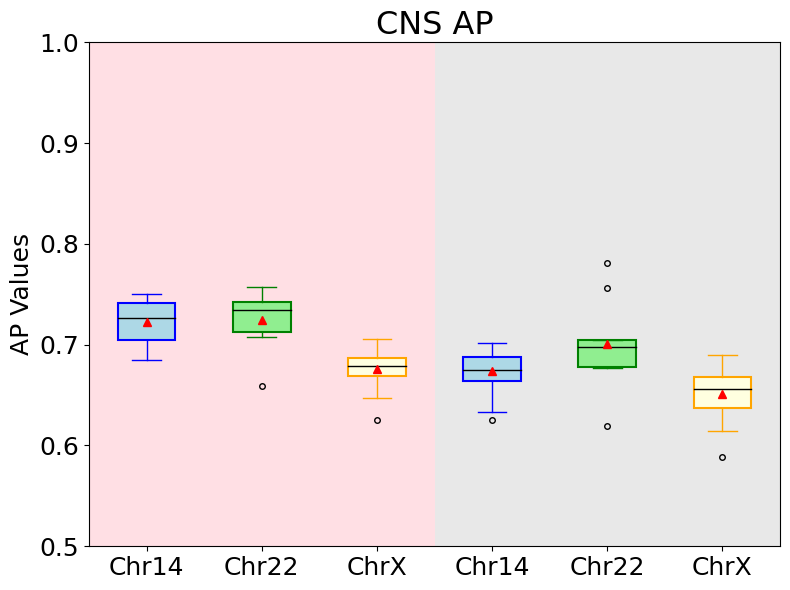

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Creating data for six datasets
data1 = chr_GM12878["chr14"][5]
data2 = chr_GM12878["chr22"][5]
data3 = chr_GM12878["chrX"][5]
data4 = chr_K562["chr14"][5]
data5 = chr_K562["chr22"][5]
data6 = chr_K562["chrX"][5]

data = [data1, data2, data3, data4, data5, data6]

# Creating the boxplot
fig, ax = plt.subplots(figsize=(8, 6))
box = ax.boxplot(data, patch_artist=True, showmeans=True)



# Setting colors for the boxplots
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightblue', 'lightgreen', 'lightyellow']
border_colors = ['blue', 'green', 'orange', 'blue', 'green', 'orange']
whisker_colors = [border_colors[i // 2] for i in range(len(box['whiskers']))]

# Setting error bar (whiskers and caps) colors
for whisker_pair, cap_pair, color in zip(box['whiskers'], box['caps'], whisker_colors):
    whisker_pair.set(color=color)
    cap_pair.set(color=color)

# Setting box facecolor and edgecolor
for patch, color, border_color in zip(box['boxes'], colors, border_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(border_color)
    patch.set_linewidth(1.5)

# Setting medians, means, and fliers styles
for element in ['medians', 'fliers']:
    plt.setp(box[element], color='black', markersize=4)

# Change mean marker color and edgecolor
for mean_marker in box['means']:
    mean_marker.set(marker='^', markerfacecolor='red', markeredgecolor='red', markersize=6)

# Setting axis labels and title
ax.set_xticklabels(['Chr14', 'Chr22', 'ChrX', 'Chr14', 'Chr22', 'ChrX'], fontsize=18)
ax.set_ylabel('AP Values', fontsize=18)

plt.title('CNS AP', fontsize=23)

ax.set_ylim(0.5,1)

# Draw a vertical line to separate the halves
#ax.axvline(x=3.5, color='black', linestyle='--')  # Adjust position here

# Set background colors for left and right halves
ax.axvspan(0.5, 3.5, facecolor='pink', alpha=0.5)  # Left half color
ax.axvspan(3.5, 6.5, facecolor='lightgrey', alpha=0.5)        # Right half color


ax.tick_params(axis='y', labelsize=18)

# Setting plot margins
plt.tight_layout()

# Save the image
plt.savefig('boxplot.png', dpi=300)

# Display the plot
plt.show()
